In [44]:
import dataclasses
import itertools
import logging
import os
import shutil
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Iterable, Tuple

from sklearn.metrics import mean_squared_error

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.widgets  # Cursor


import seaborn as sns


import numpy as np
import pandas as pd
import polars as pl
import pprintpp
import scipy.integrate
import scipy.ndimage.interpolation


from corona_model import PROJECT_DIR, log_pth
from corona_model.countryinfo import CountryInfo
from corona_model.params import DiseaseParams, SimOpts, PlotOpts
from corona_model.world_data import CovidData


In [2]:
logger = logging.getLogger(__name__)
logging.getLogger("matplotlib").setLevel(logging.INFO)


### Load Changepoints

In [3]:
changepoints = pl.read_csv("~/experimental-COVID-tracking/case_study/data/CDPHE_TLGRF_historical.csv")

### Load Census Data

In [4]:
census = pl.read_csv("SVI_2020_US_county.csv")
colorado_census = census.filter(pl.col("STATE")=="Colorado")

### Load Case Data w/ TLGRF `r_t,c`

In [64]:
benchmark_TLGRF = pl.read_csv("benchmark_TLGRF_dataset.csv", low_memory=False)
benchmark_TLGRF = benchmark_TLGRF.with_columns(
    pl.col("date").str.strptime(pl.Date, fmt="%Y-%m-%d")
)

colorado_TLGRF = benchmark_TLGRF.filter(pl.col("state")=="Colorado")
colorado_rtc = colorado_TLGRF.select(["fips","days_from_start","r_TLGRF","county","date","rolled_cases"]).sort(["fips","date"])

# TODO: Add T_start and end for parallelization
# Feed in partial data to fit each segment

/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: DeprecationWarning: `fmt` is deprecated as an argument to `strptime`; use `format` instead.
  This is separate from the ipykernel package so we can avoid doing imports until


In [65]:
# Fill in the r_tc
fips_list = (colorado_rtc.select("fips").unique().to_pandas().values.reshape(1,-1))[0]

In [66]:
fips_list

array([8001, 8003, 8005, 8007, 8009, 8011, 8013, 8014, 8015, 8017, 8019,
       8021, 8023, 8025, 8027, 8029, 8031, 8033, 8035, 8037, 8039, 8041,
       8043, 8045, 8047, 8049, 8051, 8053, 8055, 8057, 8059, 8061, 8063,
       8065, 8067, 8069, 8071, 8073, 8075, 8077, 8079, 8081, 8083, 8085,
       8087, 8089, 8091, 8093, 8095, 8097, 8099, 8101, 8103, 8105, 8107,
       8109, 8111, 8113, 8115, 8117, 8119, 8121, 8123, 8125])

In [67]:
np.where(fips_list == 8081),np.where(fips_list == 8097)

((array([41]),), (array([49]),))

In [55]:
len(fips_list)

64

In [8]:
if not os.path.exists("filtered_colorado_df.csv"):
    filtered_df_list = []
    for fips in fips_list:  
        fips_df = colorado_rtc.filter(pl.col("fips")==fips)
        # Step 1: Sort the data by 'days_from_start'
        test_df = fips_df.sort("days_from_start")

        first_non_null_index = test_df.filter(pl.col('r_TLGRF').is_not_null())['days_from_start'][0]
        test_df = test_df.filter(pl.col('days_from_start') >= first_non_null_index)

        # Step 3: Filter out trailing nulls
        # Find the last non-null index
        last_non_null_index = test_df.filter(pl.col('r_TLGRF').is_not_null())['days_from_start'][-1]
        test_df = test_df.filter(pl.col('days_from_start') <= last_non_null_index)

        # Step 4: Forward fill the intermediate null values
        # Use the forward_fill function to fill nulls in 'r_TLGRF'
        test_df = test_df.with_columns(
            pl.col('r_TLGRF').forward_fill().alias('r_TLGRF')
        )
        filtered_df = test_df.filter(
            (test_df['r_TLGRF'].is_not_null()) & (test_df['rolled_cases'].is_not_null())
        )
        filtered_df_list.append(filtered_df)
    filtered_colorado_df = pl.concat(filtered_df_list)
    filtered_colorado_df.write_csv("filtered_colorado_df.csv")
else:
    filtered_colorado_df = pl.read_csv("filtered_colorado_df.csv")

In [9]:
filtered_colorado_df

fips,days_from_start,r_TLGRF,county,date,rolled_cases
i64,i64,f64,str,str,f64
8001,65,0.249144,"""Adams""","""2020-03-26""",26.285714
8001,66,0.257155,"""Adams""","""2020-03-27""",34.714286
8001,67,0.25877,"""Adams""","""2020-03-28""",46.285714
8001,68,0.235709,"""Adams""","""2020-03-29""",59.428571
8001,69,0.241234,"""Adams""","""2020-03-30""",77.714286
8001,70,0.229009,"""Adams""","""2020-03-31""",100.285714
8001,71,0.204605,"""Adams""","""2020-04-01""",125.428571
8001,72,0.195639,"""Adams""","""2020-04-02""",155.428571
8001,73,0.17241,"""Adams""","""2020-04-03""",187.0


In [10]:
filtered_colorado_df.schema

{'fips': Int64,
 'days_from_start': Int64,
 'r_TLGRF': Float64,
 'county': Utf8,
 'date': Utf8,
 'rolled_cases': Float64}

In [11]:
beginning_of_month_T = pl.read_csv("beginning_of_month_T.csv")

In [12]:
test_T_interval = beginning_of_month_T.to_pandas().values[0:2,1]

In [39]:
T_points_list = beginning_of_month_T.to_pandas().values[:,1]
T_interval_list = [T_points_list[i:i+2] for i in range(0, len(T_points_list) - 1)]


In [40]:
T_interval_list

[array([71, 101], dtype=object),
 array([101, 132], dtype=object),
 array([132, 162], dtype=object),
 array([162, 193], dtype=object),
 array([193, 224], dtype=object),
 array([224, 254], dtype=object),
 array([254, 285], dtype=object),
 array([285, 315], dtype=object),
 array([315, 346], dtype=object),
 array([346, 377], dtype=object),
 array([377, 405], dtype=object),
 array([405, 436], dtype=object),
 array([436, 466], dtype=object),
 array([466, 497], dtype=object),
 array([497, 527], dtype=object),
 array([527, 558], dtype=object),
 array([558, 589], dtype=object),
 array([589, 619], dtype=object),
 array([619, 650], dtype=object),
 array([650, 680], dtype=object),
 array([680, 711], dtype=object),
 array([711, 742], dtype=object),
 array([742, 770], dtype=object),
 array([770, 801], dtype=object),
 array([801, 831], dtype=object),
 array([831, 862], dtype=object),
 array([862, 892], dtype=object),
 array([892, 923], dtype=object),
 array([923, 954], dtype=object),
 array([954, 98

In [13]:
def init_params(fips: int, T_interval: np.ndarray):
    # Obtain earliest t with TLGRF r_tc
    # Then obtain earliest case numbers
    fips_pop =  colorado_census.filter(pl.col("FIPS")==fips).select("E_TOTPOP").to_pandas().values[0][0]
    
    fips_df = filtered_colorado_df.filter(pl.col("fips")==fips)
    fips_df = fips_df.filter(pl.col("days_from_start") < T_interval[1])
    fips_df = fips_df.filter(pl.col("days_from_start") >= T_interval[0])
    
    # Check if empty
    correctness = True

    if fips_df.is_empty():
        print("fips={} is empty from {} <= T < {}".format(fips, T_interval[0], T_interval[1]))
        correctness = False
        return {"T": []}, correctness
    # Step 1: Sort the data by 'days_from_start'
    test_df = fips_df.sort("days_from_start")
    
    # Obtain beta_tc
    test_rtc = fips_df.select(['days_from_start','r_TLGRF']).to_pandas().values
    test_rolled_cases = fips_df.select(['days_from_start','rolled_cases']).to_pandas().values
    T = fips_df.select(['days_from_start']).to_pandas().values.astype(int).reshape(1,-1)[0]
    date = fips_df.select(['date']).to_pandas().values.reshape(1,-1)[0]
    
    # Extract the required columns and return as a tuple
    result = {
        "T": T,
        "date": date,
        "r_init": fips_df.head(1)['r_TLGRF'][0],
        "r_tc": test_rtc,
        "test_rolled_cases": test_rolled_cases,
        "I_init" :fips_df.head(1)['rolled_cases'][0],
        "S_init": fips_pop
    }
    return result, correctness

In [14]:
a,b = (init_params(fips=8003, T_interval=beginning_of_month_T.to_pandas().values[0:2,1]))

fips=8003 is empty from 71 <= T < 101


In [15]:
b

False

### Setup SEIR

In [16]:
@dataclass()
class DiseaseParams:
    """
    Disease parameters. Model is VERY sensitive to these, so they must be picked carefully from
    good sources.
    """
    fips: int
    T_interval: np.ndarray
    gamma: float = 1.0 / (10 + 3) 
    # The rate at which an exposed person becomes infective.
    sigma: float = 1.0 / (5 - 3)

    # New attributes to be initialized via init_params
    date: datetime.date = field(init=False)
    T: np.ndarray = field(init=False)
    r_init: float = field(init=False)
    r_tc: np.ndarray = field(init=False)
    test_rolled_cases: np.ndarray = field(init=False)
    I_init: float = field(init=False)
    S_init: int = field(init=False)
    
    beta: np.ndarray = field(init=False) 
    correctness: bool = field(init=False)
    
    def __post_init__(self):
        # Call init_params to get the initialization values
        params, correctness = init_params(self.fips, self.T_interval)
        self.correctness = correctness            
        if self.correctness:
            # Set the attributes from the dictionary
            self.T = params['T']
            self.date = params['date']
            self.r_init = params['r_init']
            self.r_tc = params['r_tc']
            self.test_rolled_cases = params['test_rolled_cases']
            self.I_init = params['I_init']
            self.S_init = params['S_init']


            # Initialize test_beta with the same number of rows as r_tc and 2 columns
            test_beta = np.zeros_like(self.r_tc)

            # Update test_beta array: first column from r_tc, second column calculation
            test_beta[:, 0] = self.r_tc[:, 0].astype(int)
            test_beta[:, 1] = ((self.r_tc[:, 1] * 2 + (self.sigma + self.gamma))**2 - (self.sigma - self.gamma)**2) / (4 * self.sigma)

            # Convert the list of tuples to a tuple of tuples
            self.beta = test_beta
        else:
            # Set the attributes from the dictionary
            self.T = None
            self.date = None
            self.r_init = None
            self.r_tc = None
            self.test_rolled_cases = None
            self.I_init = None
            self.S_init = None
            self.beta = None



def model_seir(t: float, state: Iterable[np.ndarray], d_params: DiseaseParams) -> Tuple[float, float, float, float, float]:
    """
    Definition of SEIR model
    :param t: Time-step (days), dependant variable of ODEs
    :param state: Vector of ODE State variables [S, E, I, R]
    :param d_params: DiseaseParams dataclass from params, or your own/modified version
    :param s_opts: SimOpts dataclass from params, or your own/modified version
    :returns: 4-element tuple of change in each of the state variables
    """
    N = d_params.S_init  # Population of country
    S, E, I, R = state
    
    #print("Current t={}, state={}".format(t, state))
    
    # Time steps are "continuous", use latest value of beta_t,c
    beta = d_params.beta[d_params.beta[:, 0] <= t][-1, 1]
    
    sigma = d_params.sigma
    gamma = d_params.gamma

    dS = - beta * S * I / N
    dE = beta * S * I / N  - sigma * E
    dI = sigma * E - gamma * I
    dR = gamma * I

    return dS, dE, dI, dR

def run_model(d_params: DiseaseParams) -> Tuple[float, float, float, float]:
    """
    Solves the ODE model and returns results.
    :param d_params: d_params: DiseaseParams dataclass from params, or your own/modified version
    :param s_opts: s_opts: SimOpts dataclass from params, or your own/modified version
    :returns: 5-element Tuple of arrays of results
    """
    T = d_params.T  # time-step Array
    
    # Run in chunks    
    Y0 = [d_params.S_init - d_params.I_init, 0, d_params.I_init, 0]  # S, E, I, R at initial step

    logger.info(f"Starting run of model...")
    logger.info(f"DiseaseParams : {pprintpp.pformat(dataclasses.asdict(d_params))}")
    logger.info(f"Initial conditions (S E I R): {Y0}")
    
    
    
    Y_RESULTS = scipy.integrate.solve_ivp(model_seir, t_span=[T[0], T[-1]],
                                          y0=Y0, args=(d_params,),
                                          t_eval=T)

    S, E, I, R = Y_RESULTS.y  # transpose and unpack

    logger.info(f"Solve complete!")
    
    results_dict = {"T":T, "S":S, "E":E, "I":I, "R":R}
    results_dict["rolled_cases"] = d_params.test_rolled_cases[:,1]
    results_dict["date"] = d_params.date
    
    # Compute R0
    R0 = (d_params.r_tc[:,1]+d_params.gamma)*(d_params.r_tc[:,1]+d_params.sigma)/(d_params.sigma*d_params.gamma)
    results_dict["R0"] = R0
    
    rmse = mean_squared_error(results_dict["rolled_cases"], results_dict["I"])**0.5
    
    df = pd.DataFrame(results_dict)

    # Set the 'T' column as the index
    df.set_index('T', inplace=True)

    return df, rmse


### Call Model

Parallelize this part

In [32]:
test_fips = 8001
test_gamma = 1.0 / (10 + 3) 
test_sigma = 1.0 / (5 - 3)
test_T_interval = beginning_of_month_T.to_pandas().values[4:6,1]
#test_gamma = 0.9
#test_sigma = 0.1

def simulate(fips=test_fips, T_interval=test_T_interval, sigma=test_sigma, gamma=test_gamma):
    disease_params = DiseaseParams(fips=fips, T_interval=T_interval, sigma=sigma, gamma=gamma)
    if not disease_params.correctness:
        return None, None, None
    results, rmse = run_model(disease_params)

    return disease_params, results, rmse

In [41]:
disease_params, results, rmse = simulate(fips=test_fips, T_interval=test_T_interval, gamma=test_gamma, sigma=test_sigma)

2024-09-07 19:20:54,356 - __main__ - INFO - Starting run of model...
2024-09-07 19:20:54,361 - __main__ - INFO - DiseaseParams : {
    'I_init': 1314.0,
    'S_init': 509844,
    'T': array([193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205,
           206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218,
           219, 220, 221, 222, 223]),
    'T_interval': array([193, 224], dtype=object),
    'beta': array([[1.93000000e+02, 9.42065218e-02],
           [1.94000000e+02, 9.29989580e-02],
           [1.95000000e+02, 9.08131323e-02],
           [1.96000000e+02, 8.78370377e-02],
           [1.97000000e+02, 8.85270074e-02],
           [1.98000000e+02, 8.71873200e-02],
           [1.99000000e+02, 8.39030632e-02],
           [2.00000000e+02, 8.39265380e-02],
           [2.01000000e+02, 8.39433576e-02],
           [2.02000000e+02, 8.51099323e-02],
           [2.03000000e+02, 8.26326908e-02],
           [2.04000000e+02, 8.33511003e-02],
           [2.05000000e+02, 8.3

In [34]:
results

,S,E,I,R,rolled_cases,date,R0
T,,,,,,,
193,508530.000000,0.000000,1314.000000,0.000000,1314.000000,2020-08-01,1.224685
194,508410.349533,93.936665,1241.750692,97.963111,1328.285714,2020-08-02,1.208986
195,508297.245683,145.783277,1208.927165,192.043875,1341.714286,2020-08-03,1.180571
196,508189.481722,172.973853,1197.072839,284.471586,1353.142857,2020-08-04,1.141881
197,508085.406200,186.859935,1195.281617,376.452248,1365.285714,2020-08-05,1.150851
198,507980.426892,195.950372,1199.095399,468.527338,1375.142857,2020-08-06,1.133435
199,507873.090897,203.338160,1206.546307,561.024636,1380.000000,2020-08-07,1.090740
200,507771.325636,203.361623,1215.145773,654.166968,1389.285714,2020-08-08,1.091045
201,507669.430915,203.559199,1223.061123,747.948763,1399.000000,2020-08-09,1.091264


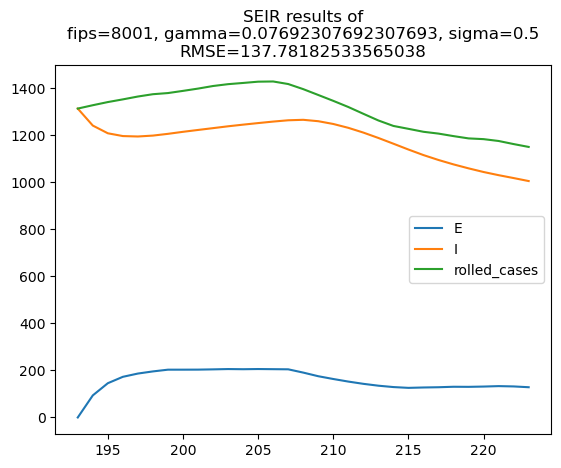

In [35]:
plt.plot(results["E"], label="E")
plt.plot(results["I"], label="I")

plt.plot(results["rolled_cases"], label="rolled_cases")


plt.title("SEIR results of\nfips={}, gamma={}, sigma={}\nRMSE={}".format(disease_params.fips, disease_params.gamma,disease_params.sigma, rmse))
plt.legend()
plt.show()

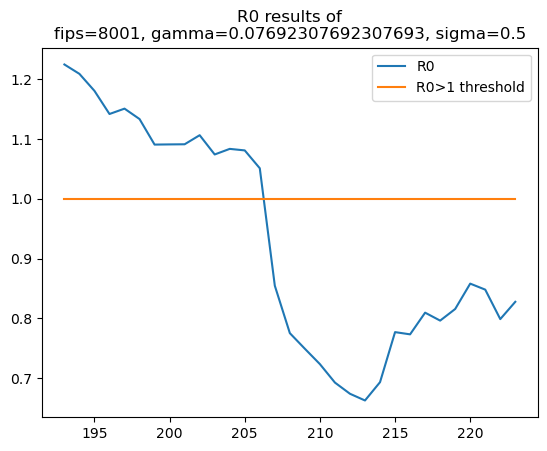

In [36]:
plt.plot(results["R0"], label="R0")
plt.plot(results.index, [1 for i in results.index], label="R0>1 threshold")

plt.title("R0 results of\nfips={}, gamma={}, sigma={}".format(disease_params.fips, disease_params.gamma,disease_params.sigma))
plt.legend()
plt.show()


In [49]:
fips_list = sorted((filtered_colorado_df.select("fips").unique().to_pandas().values.reshape(1,-1))[0])
T_interval_list = np.array([T_points_list[i:i+2] for i in range(0, len(T_points_list) - 1)])
gamma_list = np.arange(0.05, 1.0, 0.05)
sigma_list = np.arange(0.05, 1.0, 0.05)

combinations = list(itertools.product(fips_list, T_interval_list, gamma_list, sigma_list))


In [51]:
combinations[0]

(8001, array([71, 101], dtype=object), 0.05, 0.05)

In [54]:
disease_params, results, rmse = simulate(combinations[0])

TypeError: __init__() got an unexpected keyword argument 'fips'

In [53]:
*combinations[0]

SyntaxError: can't use starred expression here (2221523689.py, line 4)